In [1]:
!pip install openpyxl seaborn

In [2]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
%matplotlib inline

In [3]:
#Upload Your Dataset
from google.colab import files

uploaded = files.upload()

Saving Cleaned_Sales_Dataset.xlsx to Cleaned_Sales_Dataset.xlsx


In [4]:
#Read the Dataset
df = pd.read_excel("Cleaned_Sales_Dataset.xlsx")
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Sales_Category,Month
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,Low,February
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80,High,October
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48,High,May
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,High,December
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,High,November


In [5]:
df.shape

(1000, 14)

In [6]:
#Display Column Names
df.columns.tolist()

['Order_ID',
 'Order_Date',
 'Customer_ID',
 'Customer_Name',
 'Age',
 'Gender',
 'City',
 'Product',
 'Category',
 'Quantity',
 'Unit_Price',
 'Total_Sales',
 'Sales_Category',
 'Month']

In [7]:
#Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order_ID        1000 non-null   object        
 1   Order_Date      1000 non-null   datetime64[ns]
 2   Customer_ID     1000 non-null   object        
 3   Customer_Name   1000 non-null   object        
 4   Age             1000 non-null   float64       
 5   Gender          1000 non-null   object        
 6   City            1000 non-null   object        
 7   Product         1000 non-null   object        
 8   Category        1000 non-null   object        
 9   Quantity        1000 non-null   int64         
 10  Unit_Price      1000 non-null   float64       
 11  Total_Sales     1000 non-null   float64       
 12  Sales_Category  1000 non-null   object        
 13  Month           1000 non-null   object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(9)
mem

In [8]:
#Descriptive Statistics
df.describe()

,Order_Date,Age,Quantity,Unit_Price,Total_Sales
count,1000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2025-07-03 11:19:40.800000,41.360204,5.435000,25486.783410,139399.439650
min,2025-01-01 00:00:00,18.000000,1.000000,145.780000,437.340000
25%,2025-03-30 18:00:00,30.000000,3.000000,13895.722500,47066.632500
50%,2025-07-01 00:00:00,41.000000,5.000000,25398.740000,108594.025000
75%,2025-10-07 06:00:00,53.000000,8.000000,37512.382500,203722.882500
max,2026-01-01 00:00:00,65.000000,10.000000,49997.530000,493677.500000
std,NaN,13.683533,2.838632,14179.402361,114100.051546


In [9]:
df.describe(include='object')

,Order_ID,Customer_ID,Customer_Name,Gender,City,Product,Category,Sales_Category,Month
count,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,992,947,425,2,8,6,5,2,12
top,ORD100050,CUST2515,Customer_359,Male,Patna,Mobile,Electronics,Low,December
freq,9,3,8,511,148,184,354,500,98


In [10]:
#Missing Values
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Customer_Name,0
Age,0
Gender,0
City,0
Product,0
Category,0
Quantity,0


In [11]:
df.duplicated().sum()

np.int64(0)

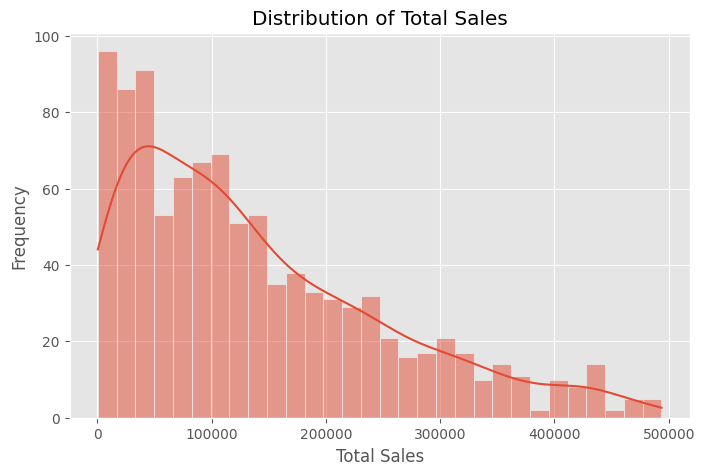

In [12]:
#Sales Distribution (Histogram)
plt.figure(figsize=(8,5))

sns.histplot(df["Total_Sales"], bins=30, kde=True)

plt.title("Distribution of Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")

plt.show()

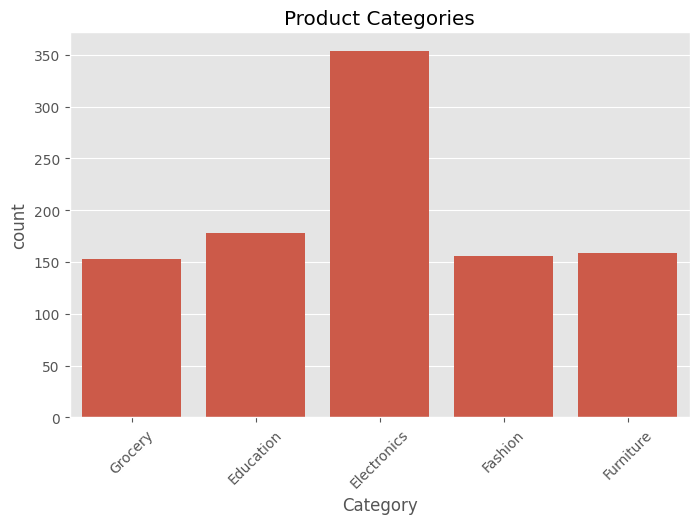

In [13]:
#Product Category Distribution
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Category")

plt.xticks(rotation=45)

plt.title("Product Categories")

plt.show()

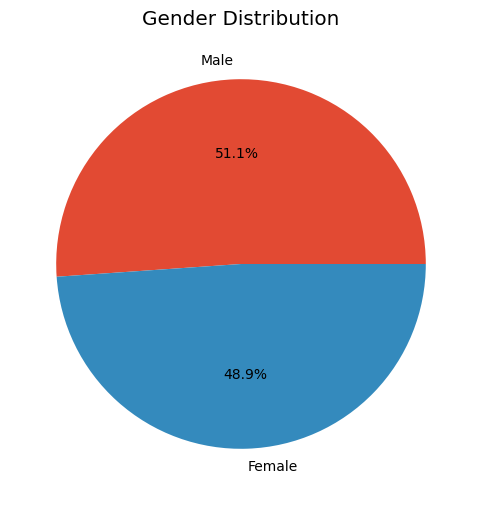

In [14]:
#Gender Distribution
plt.figure(figsize=(6,6))

df["Gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Gender Distribution")

plt.show()

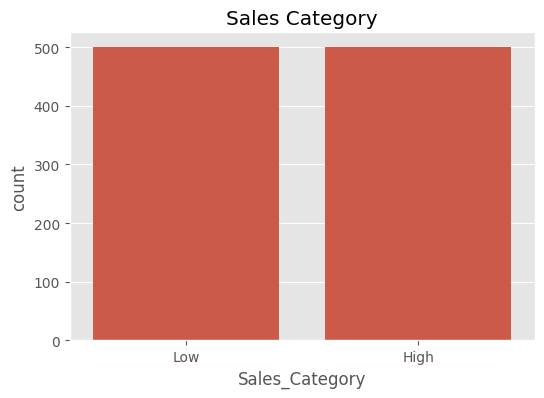

In [15]:
#Sales Category Distribution
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Sales_Category")

plt.title("Sales Category")

plt.show()

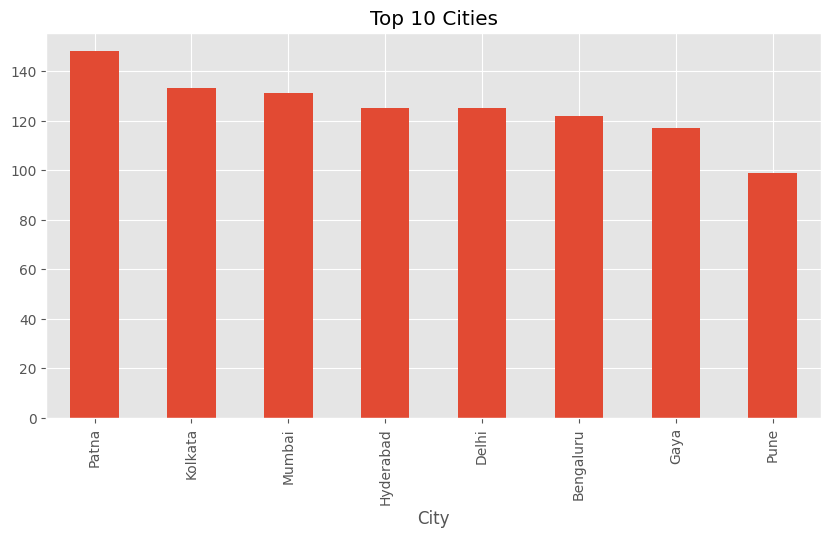

In [16]:
#Top 10 Cities
plt.figure(figsize=(10,5))

df["City"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Cities")

plt.show()

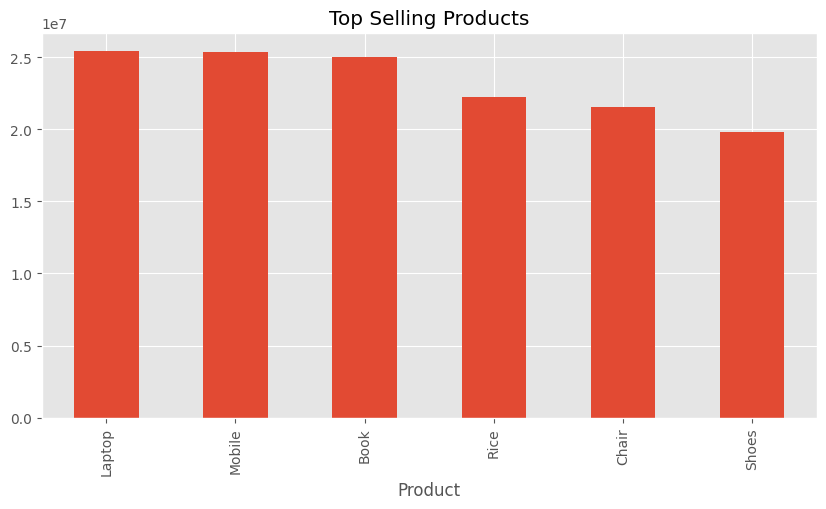

In [17]:
#Top Selling Products
top_products = df.groupby("Product")["Total_Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

top_products.plot(kind="bar")

plt.title("Top Selling Products")

plt.show()

In [18]:
#Correlation Matrix
corr = df.select_dtypes(include=['number']).corr()

corr

,Age,Quantity,Unit_Price,Total_Sales
Age,1.000000,-0.027329,-0.012071,0.001456
Quantity,-0.027329,1.000000,0.021855,0.646641
Unit_Price,-0.012071,0.021855,1.000000,0.686303
Total_Sales,0.001456,0.646641,0.686303,1.000000


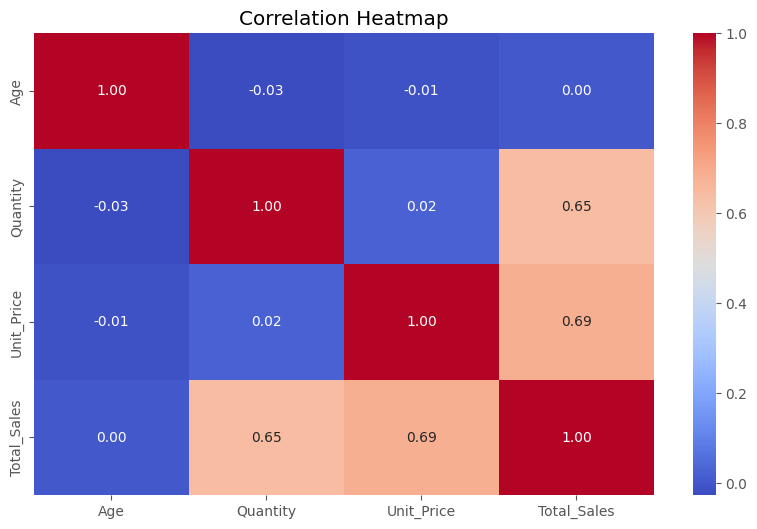

In [19]:
#Correlation Heatmap
plt.figure(figsize=(10,6))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

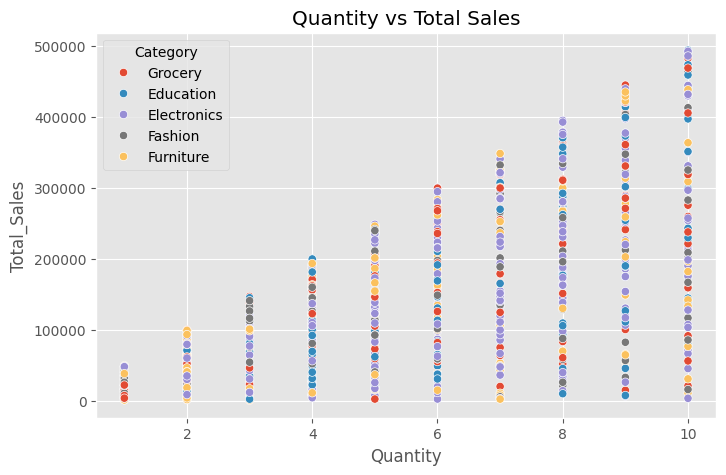

In [20]:
#Scatter Plot (Quantity vs Total Sales)
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Quantity",
    y="Total_Sales",
    hue="Category"
)

plt.title("Quantity vs Total Sales")

plt.show()

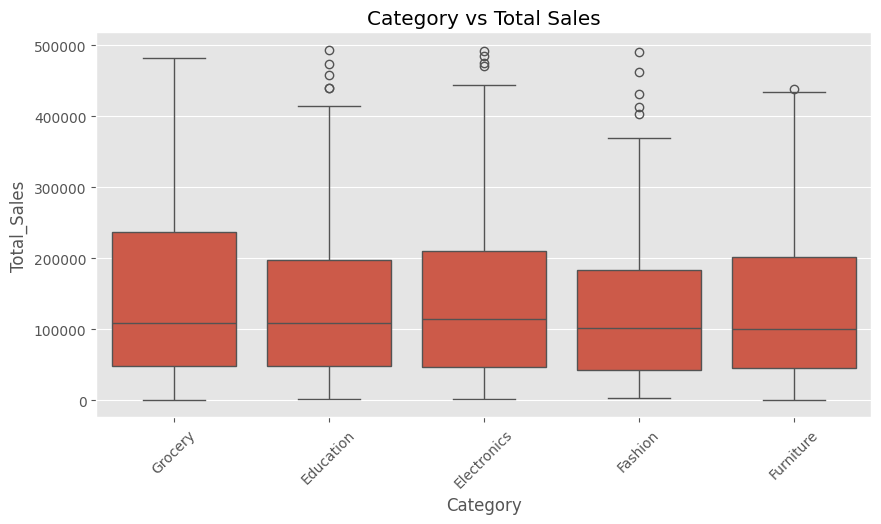

In [21]:
#Box Plot
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="Category",
    y="Total_Sales"
)

plt.xticks(rotation=45)

plt.title("Category vs Total Sales")

plt.show()

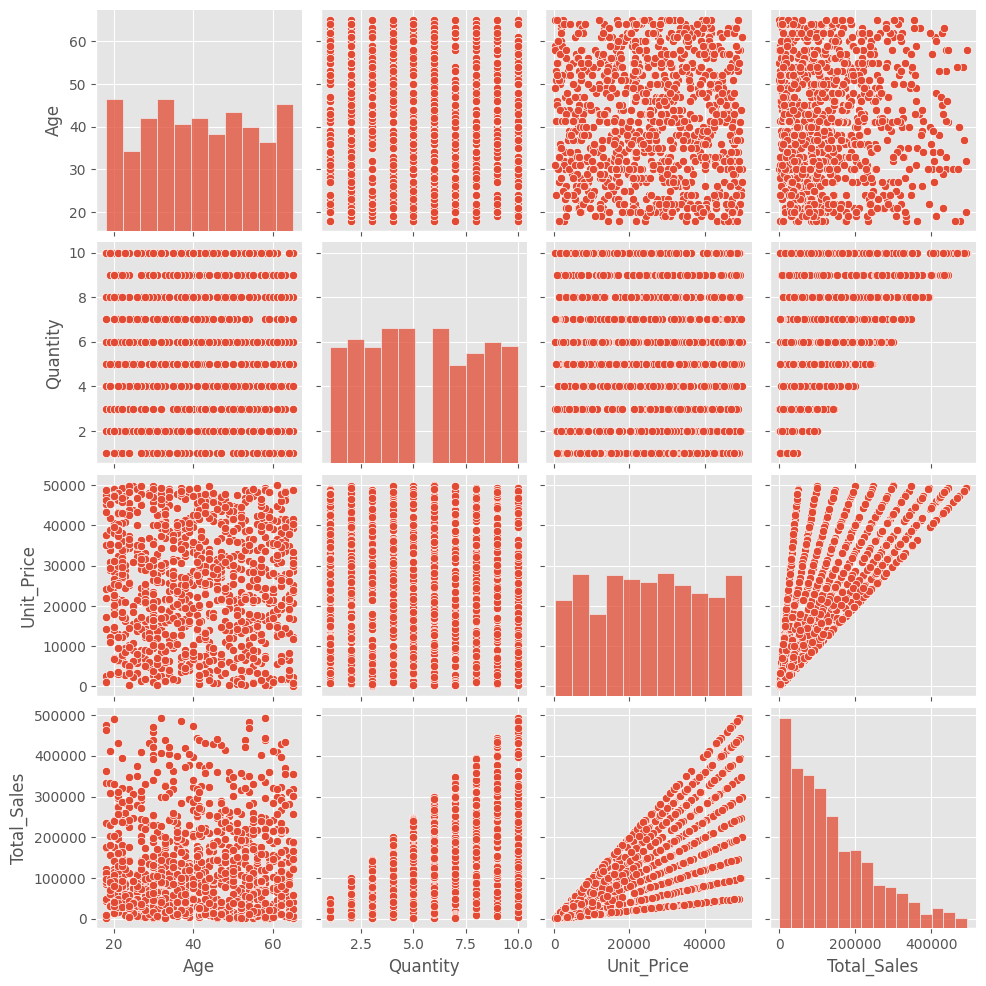

In [22]:
#Pair Plot
sns.pairplot(
    df[["Age","Quantity","Unit_Price","Total_Sales"]]
)

plt.show()

In [23]:
#Business Insights
#Top 10 Products
df.groupby("Product")["Total_Sales"]\
.sum()\
.sort_values(ascending=False)\
.head(10)



,Total_Sales
Product,
Laptop,25443008.51
Mobile,25335573.19
Book,25031689.40
Rice,22231711.28
Chair,21521561.48
Shoes,19835895.79


In [24]:
#Category Wise Sales
df.groupby("Category")["Total_Sales"].sum()

,Total_Sales
Category,
Education,25031689.40
Electronics,50778581.70
Fashion,19835895.79
Furniture,21521561.48
Grocery,22231711.28


In [25]:
#City Wise Sales
df.groupby("City")["Total_Sales"]\
.sum()\
.sort_values(ascending=False)

,Total_Sales
City,
Patna,20826584.43
Kolkata,18884349.57
Bengaluru,18773574.32
Mumbai,18757050.17
Hyderabad,17166766.87
Delhi,16097079.00
Pune,14513175.90
Gaya,14380859.39


In [26]:
#Average Sales
df["Total_Sales"].mean()

np.float64(139399.43965000001)

In [27]:
#Highest Unit Price
df["Unit_Price"].max()

49997.53

In [28]:
#Sales by Gender
df.groupby("Gender")["Total_Sales"].sum()

,Total_Sales
Gender,
Female,66935889.02
Male,72463550.63


In [29]:
#Monthly Sales
df.groupby("Month")["Total_Sales"].sum()

,Total_Sales
Month,
April,12222700.17
August,9448471.22
December,12299904.44
February,11511181.46
January,10905580.72
July,11746226.80
June,12912332.64
March,13059899.94
May,10984689.25


**SQL Business Questions**

In [30]:
import sqlite3
import pandas as pd

# Connect to SQLite database
conn = sqlite3.connect("sales.db")

# Store DataFrame as SQL table
df.to_sql("Sales", conn, if_exists="replace", index=False)

print("Database created successfully!")

Database created successfully!


In [31]:
#Total Sales
query = """
SELECT SUM(Total_Sales) AS Total_Sales
FROM Sales;
"""

pd.read_sql(query, conn)

,Total_Sales
0,1.393994e+08


In [32]:
#Average Sales
query = """
SELECT AVG(Total_Sales) AS Average_Sales
FROM Sales;
"""

pd.read_sql(query, conn)

,Average_Sales
0,139399.43965


In [33]:
#Top 10 Products
query = """
SELECT Product,
SUM(Total_Sales) AS Revenue
FROM Sales
GROUP BY Product
ORDER BY Revenue DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,Product,Revenue
0,Laptop,25443008.51
1,Mobile,25335573.19
2,Book,25031689.40
3,Rice,22231711.28
4,Chair,21521561.48
5,Shoes,19835895.79


In [34]:
#Sales by Category
query = """
SELECT Category,
SUM(Total_Sales) AS Sales
FROM Sales
GROUP BY Category;
"""

pd.read_sql(query, conn)

,Category,Sales
0,Education,25031689.40
1,Electronics,50778581.70
2,Fashion,19835895.79
3,Furniture,21521561.48
4,Grocery,22231711.28


In [35]:
#Sales by Gender
query = """
SELECT Gender,
SUM(Total_Sales) AS Sales
FROM Sales
GROUP BY Gender;
"""

pd.read_sql(query, conn)

,Gender,Sales
0,Female,66935889.02
1,Male,72463550.63


In [36]:
#Monthly Sales
query = """
SELECT Month,
SUM(Total_Sales) AS Sales
FROM Sales
GROUP BY Month;
"""

pd.read_sql(query, conn)

,Month,Sales
0,April,12222700.17
1,August,9448471.22
2,December,12299904.44
3,February,11511181.46
4,January,10905580.72
5,July,11746226.80
6,June,12912332.64
7,March,13059899.94
8,May,10984689.25
9,November,12627620.22


In [37]:
#Top Cities
query = """
SELECT City,
SUM(Total_Sales) AS Sales
FROM Sales
GROUP BY City
ORDER BY Sales DESC;
"""

pd.read_sql(query, conn)

,City,Sales
0,Patna,20826584.43
1,Kolkata,18884349.57
2,Bengaluru,18773574.32
3,Mumbai,18757050.17
4,Hyderabad,17166766.87
5,Delhi,16097079.00
6,Pune,14513175.90
7,Gaya,14380859.39


In [38]:
conn.close()

**Dashboard**

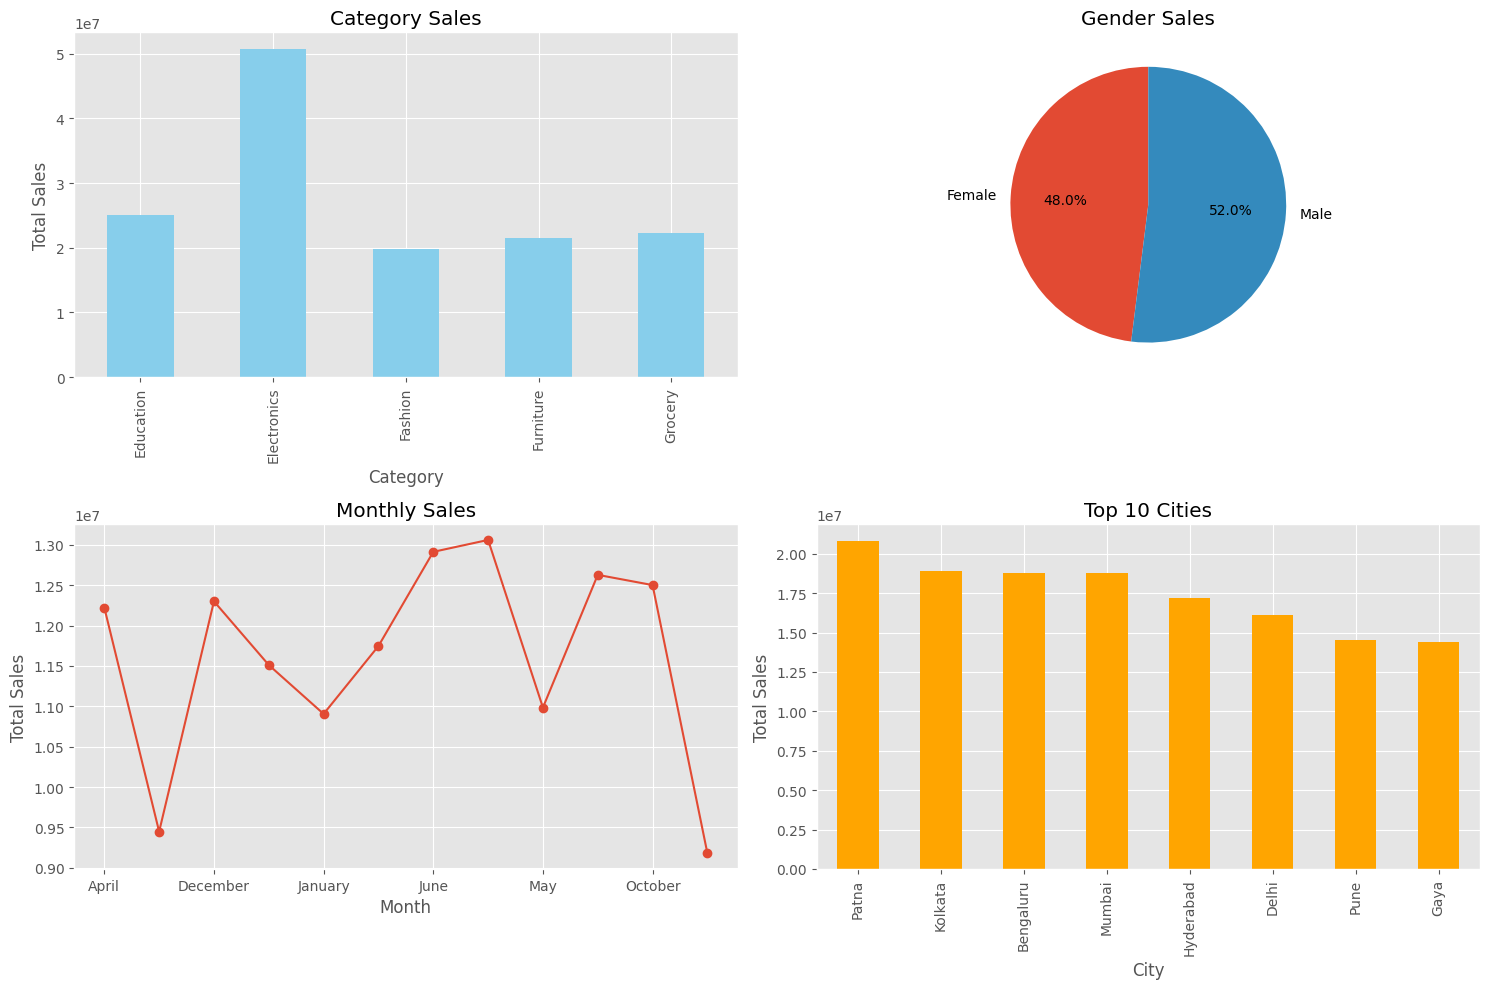

In [39]:
plt.figure(figsize=(15,10))

# Chart 1: Category Sales
plt.subplot(2,2,1)
df.groupby("Category")["Total_Sales"].sum().plot(kind="bar", color="skyblue")
plt.title("Category Sales")
plt.xlabel("Category")
plt.ylabel("Total Sales")

# Chart 2: Gender Sales
plt.subplot(2,2,2)
df.groupby("Gender")["Total_Sales"].sum().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)
plt.ylabel("")
plt.title("Gender Sales")

# Chart 3: Monthly Sales
plt.subplot(2,2,3)
df.groupby("Month")["Total_Sales"].sum().plot(
    kind="line",
    marker="o"
)
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")

# Chart 4: Top 10 Cities
plt.subplot(2,2,4)
df.groupby("City")["Total_Sales"].sum().sort_values(ascending=False).head(10).plot(
    kind="bar",
    color="orange"
)
plt.title("Top 10 Cities")
plt.xlabel("City")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.show()

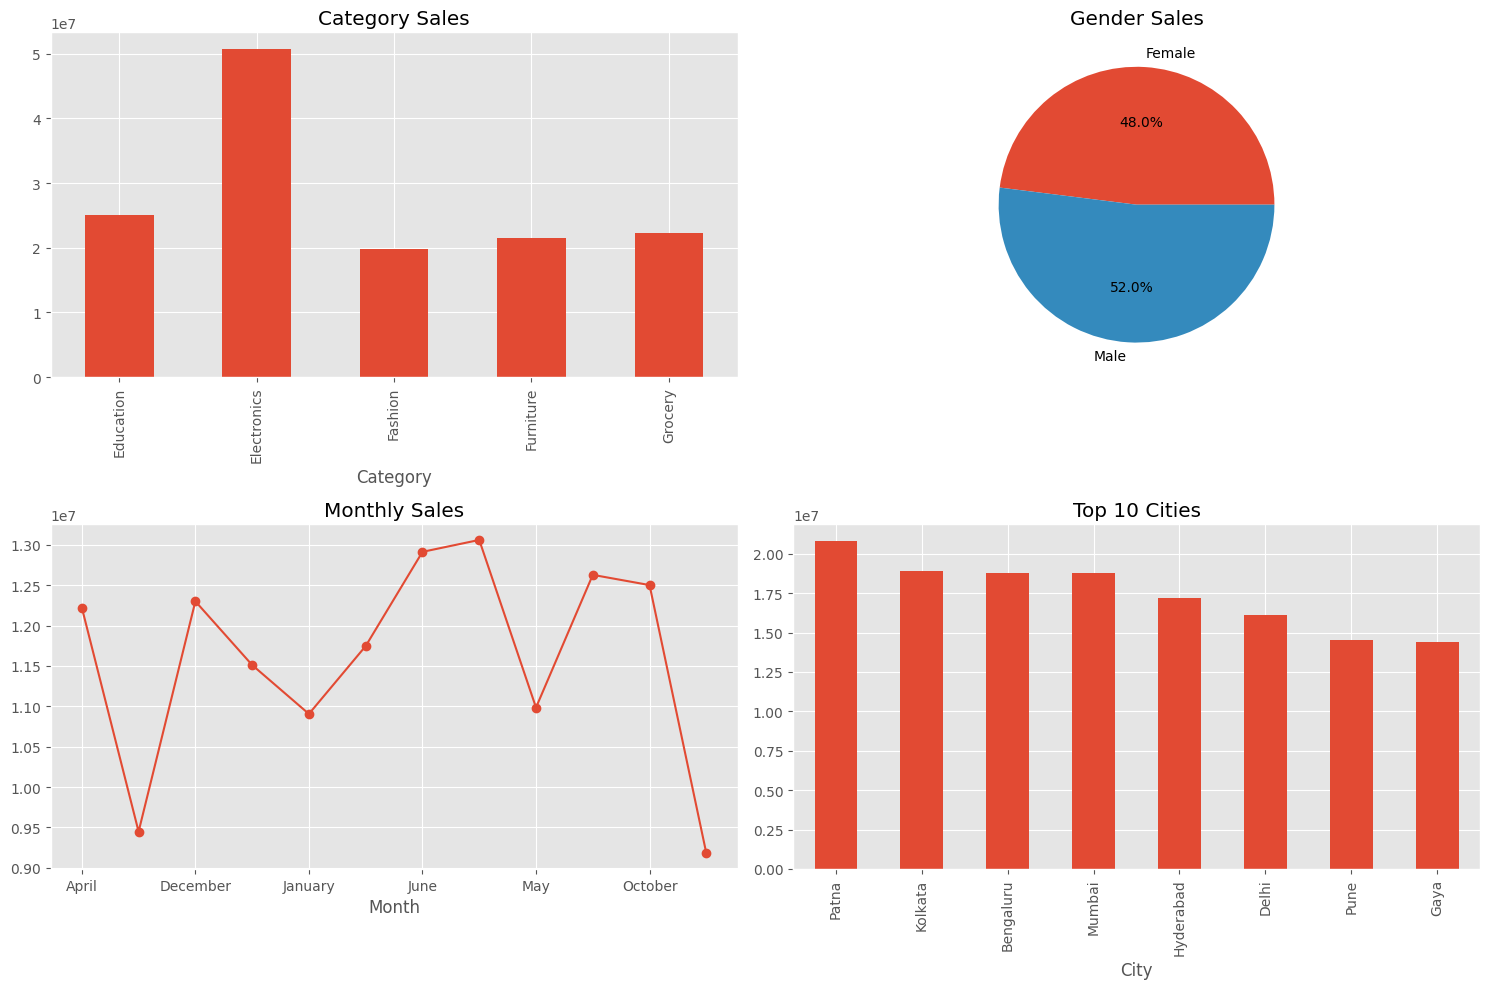

In [40]:
plt.figure(figsize=(15,10))

# Chart 1
plt.subplot(2,2,1)
df.groupby("Category")["Total_Sales"].sum().plot(kind="bar")
plt.title("Category Sales")

# Chart 2
plt.subplot(2,2,2)
df.groupby("Gender")["Total_Sales"].sum().plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Gender Sales")

# Chart 3
plt.subplot(2,2,3)
df.groupby("Month")["Total_Sales"].sum().plot(kind="line", marker="o")
plt.title("Monthly Sales")

# Chart 4
plt.subplot(2,2,4)
df.groupby("City")["Total_Sales"].sum().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 Cities")

plt.tight_layout()

# Save image
plt.savefig("Dashboard.png", dpi=300, bbox_inches="tight")

plt.show()